In [20]:
# GPU availability check
import torch
import sys

print("Python version:", sys.version)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("Number of GPUs:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
        print(f"  Memory: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.1f} GB")
    print("Current device:", torch.cuda.current_device())
    print("Device name:", torch.cuda.get_device_name())
else:
    print("CUDA is not available")
    print("Available devices:", "CPU only")

Python version: 3.9.22 | packaged by conda-forge | (main, Apr 14 2025, 23:35:59) 
[GCC 13.3.0]
PyTorch version: 2.5.1
CUDA available: False
CUDA is not available
Available devices: CPU only


# UMAP Visualization Script for PBMC68k NoConstraint Dataset

This script analyzes the generated samples from the pbmc68k_NoConstraint_20250929 model.
- Loads the generated gene expression data directly (no autoencoder decoding needed)
- Creates UMAP visualizations comparing real vs generated cells
- Performs basic quality checks and correlation analysis

In [21]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import sys
import warnings
warnings.filterwarnings('ignore')

# Set up scanpy settings
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor='white')

print("Environment set up successfully!")

Environment set up successfully!


## Load Real Data

In [22]:
# Load PBMC68k dataset and apply same preprocessing as in cell_train_20250929_NoConstraint.py
adata = sc.read_h5ad('/home/suzuki/Projects/scDiffusion/data_preparation/pbmc68k.h5ad')

print(f"Original data shape: {adata.shape}")

# Apply the same preprocessing as in cell_train_20250929_NoConstraint.py to match gene filtering
print("Applying preprocessing to match NoConstraint model training...")
sc.pp.filter_cells(adata, min_genes=10)
sc.pp.filter_genes(adata, min_cells=3)
adata.var_names_make_unique()

print(f"Data shape after filtering: {adata.shape}")
print(f"Available obs columns: {list(adata.obs.columns)}")

Original data shape: (68579, 32738)
Applying preprocessing to match NoConstraint model training...
filtered out 14949 genes that are detected in less than 3 cells
Data shape after filtering: (68579, 17789)
Available obs columns: ['TSNE.1', 'TSNE.2', 'celltype', 'n_genes']


## Prepare Real Data for Analysis

In [23]:
# Find cell type column and prepare labels
if 'celltype' in adata.obs.columns:
    cell_type_col = 'celltype'
elif 'cell_type' in adata.obs.columns:
    cell_type_col = 'cell_type'
else:
    print("Available columns:", list(adata.obs.columns))
    cell_type_col = None

if cell_type_col:
    print(f"Using cell type column: {cell_type_col}")
    print(f"Cell types: {list(adata.obs[cell_type_col].unique())}")
    celltype = adata.obs[cell_type_col]
else:
    print("Warning: No cell type column found")
    celltype = None

# Apply the same normalization as in training pipeline
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Get gene expression data (already log-normalized)
if hasattr(adata.X, 'toarray'):
    cell_data = adata.X.toarray()
else:
    cell_data = adata.X

print(f"Cell data shape: {cell_data.shape}")
print(f"Gene names: {len(adata.var_names)} genes")

# Store gene names for later use
gene_names = adata.var_names.tolist()

Using cell type column: celltype
Cell types: ['CD8+ Cytotoxic T', 'CD8+/CD45RA+ Naive Cytotoxic', 'CD4+/CD45RO+ Memory', 'CD19+ B', 'CD4+/CD25 T Reg', 'CD56+ NK', 'CD4+ T Helper2', 'CD4+/CD45RA+/CD25- Naive T', 'CD34+', 'Dendritic', 'CD14+ Monocyte']
normalizing counts per cell


    finished (0:00:00)
Cell data shape: (68579, 17789)
Gene names: 17789 genes


In [24]:
from sklearn.preprocessing import LabelEncoder

# Prepare cell type labels
print('Data shape:', adata.shape)
print('Cell types in dataset:')
print(adata.obs['celltype'].value_counts())

# Encode cell types
classes = adata.obs['celltype'].values
label_encoder = LabelEncoder()
labels = classes
label_encoder.fit(labels)
classes_encoded = label_encoder.transform(labels)

print(f'\nTotal unique cell types: {len(np.unique(labels))}')
print(f'Encoded labels range: {classes_encoded.min()} to {classes_encoded.max()}')

Data shape: (68579, 17789)
Cell types in dataset:
celltype
CD8+ Cytotoxic T                20773
CD8+/CD45RA+ Naive Cytotoxic    16666
CD56+ NK                         8776
CD4+/CD25 T Reg                  6187
CD19+ B                          5908
CD4+/CD45RO+ Memory              3061
CD14+ Monocyte                   2862
Dendritic                        2099
CD4+/CD45RA+/CD25- Naive T       1873
CD34+                             277
CD4+ T Helper2                     97
Name: count, dtype: int64

Total unique cell types: 11
Encoded labels range: 0 to 10


## Load Generated Data from NoConstraint Model

In [25]:
# Load generated samples from NoConstraint model
unconditional_path = '/home/suzuki/Projects/scDiffusion/output/simulated_samples/pbmc68k_NoConstraint_20250929.npz'

print("Loading generated samples from NoConstraint model...")
cell_gen = None

try:
    npzfile = np.load(unconditional_path, allow_pickle=True)
    print(f"Available keys in file: {list(npzfile.keys())}")

    # Load generated data
    if 'cell_gen' in npzfile.keys():
        cell_gen = npzfile['cell_gen'][:3000]  # Use 3000 samples
        print("Using 'cell_gen' key")
    elif 'arr_0' in npzfile.keys():
        cell_gen = npzfile['arr_0'][:3000]
        print("Using 'arr_0' key")
    else:
        key = list(npzfile.keys())[0]
        cell_gen = npzfile[key][:3000]
        print(f"Using key: {key}")

    print(f"Loaded generated samples shape: {cell_gen.shape}")
    print("Note: Samples are already in gene expression space")
    
    # Apply log normalization to match real data scale
    if cell_gen is not None:
        print(f"Before log normalization - min={cell_gen.min():.3f}, max={cell_gen.max():.3f}, mean={cell_gen.mean():.3f}")
        
        # Ensure non-negative values before log transformation
        cell_gen = np.maximum(cell_gen, 0)  # Clip negative values to 0
        
        # Apply log(1 + x) transformation to match real data processing
        cell_gen = np.log1p(cell_gen)
        
        print(f"After log normalization - min={cell_gen.min():.3f}, max={cell_gen.max():.3f}, mean={cell_gen.mean():.3f}")
        print(f"Final generated samples shape: {cell_gen.shape}")
    else:
        print("Failed to load generated samples")
        
except FileNotFoundError:
    print(f"Generated samples file not found at: {unconditional_path}")
    print("Please check if the pbmc68k_NoConstraint_20250929.npz file exists")
except Exception as e:
    print(f"Error loading generated samples: {e}")

Loading generated samples from NoConstraint model...
Available keys in file: ['cell_gen']


Using 'cell_gen' key
Loaded generated samples shape: (3000, 17789)
Note: Samples are already in gene expression space
Before log normalization - min=-1287.160, max=1234.747, mean=-0.332
After log normalization - min=0.000, max=7.119, mean=2.370
Final generated samples shape: (3000, 17789)


Creating combined dataset for UMAP analysis...
Combined data shape: (71579, 17789)
AnnData object created: (71579, 17789)
Cell origin distribution:
origin
Real         68579
Generated     3000
Name: count, dtype: int64
Real only: (68579, 17789), Generated only: (3000, 17789)
Generated subset: (500, 17789)
Using `adata_gen_only` (alias for adata_en_only)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
running Leiden clustering
    fi

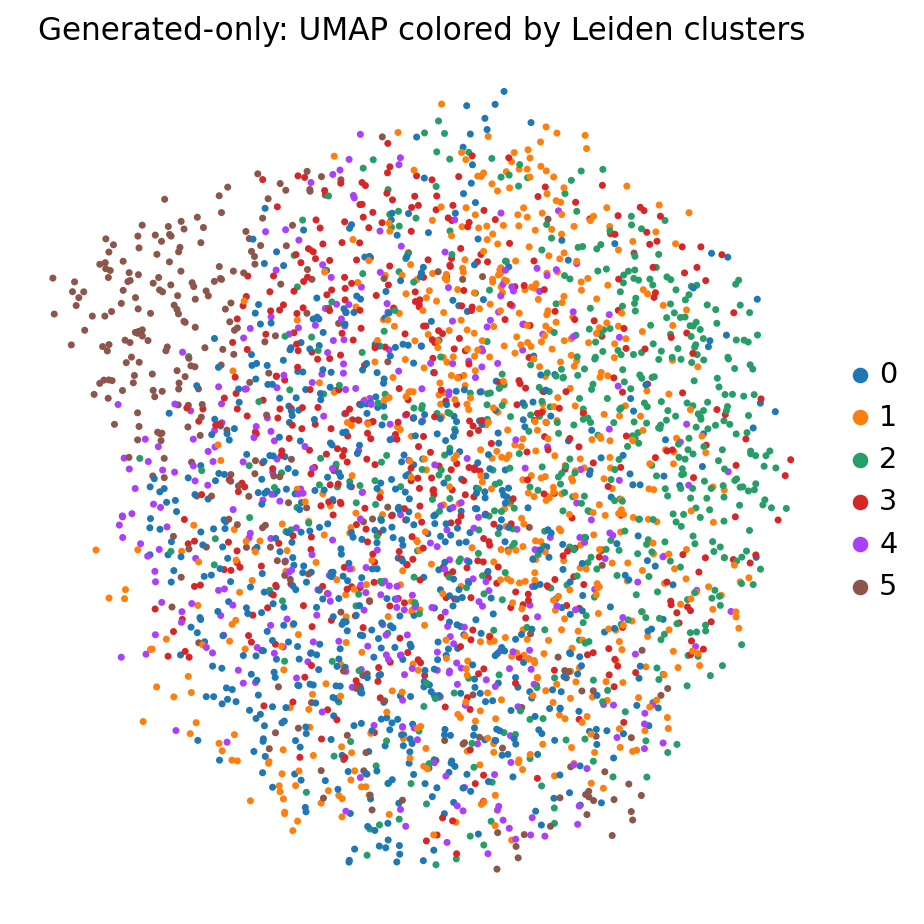

In [26]:
import numpy as np
import pandas as pd
import scanpy as sc

print("Creating combined dataset for UMAP analysis...")

if cell_gen is not None:
    # ---- 結合 ----
    combined_data = np.concatenate((cell_data, cell_gen), axis=0)
    n_real = cell_data.shape[0]
    n_gen  = cell_gen.shape[0]
    print(f"Combined data shape: {combined_data.shape}")

    adata_combined = sc.AnnData(X=combined_data)

    # ---- 行名（obs_names）を安定化：元の実細胞の名前 + 生成細胞の連番 ----
    real_names = list(getattr(adata, "obs_names", pd.Index(range(n_real))))
    gen_names  = [f"gen_{i}" for i in range(n_gen)]
    adata_combined.obs_names = real_names + gen_names

    # ---- 区別用カラム追加（後工程でのフィルタ用）----
    # 1) 文字列ラベル
    adata_combined.obs["origin"] = pd.Categorical(
        ["Real"] * n_real + ["Generated"] * n_gen,
        categories=["Real", "Generated"]
    )
    # 2) 真偽値（フィルタ・マスク用に便利）
    adata_combined.obs["is_generated"] = adata_combined.obs["origin"].eq("Generated")

    # 参考: celltype も結合（生成データは 'Generated' としておく）
    real_celltypes = adata.obs["celltype"].astype(str).tolist()
    adata_combined.obs["celltype"] = pd.Categorical(
        real_celltypes + ["Generated"] * n_gen
    )

    print(f"AnnData object created: {adata_combined.shape}")
    print("Cell origin distribution:")
    print(adata_combined.obs["origin"].value_counts())

    # ---- 分割（後で使いやすいようにここで用意しておく）----
    adata_real_only = adata_combined[~adata_combined.obs["is_generated"]].copy()
    adata_gen_only  = adata_combined[ adata_combined.obs["is_generated"]].copy()
    print(f"Real only: {adata_real_only.shape}, Generated only: {adata_gen_only.shape}")

    # ---- 一部だけ使いたい場合の例（ランダムに一部サンプル）----
    # 例: 生成細胞を最大500細胞だけ抽出
    max_take = 500
    if adata_gen_only.n_obs > 0:
        take = min(max_take, adata_gen_only.n_obs)
        idx  = np.random.choice(adata_gen_only.n_obs, size=take, replace=False)
        adata_gen_subset = adata_gen_only[idx].copy()
        print(f"Generated subset: {adata_gen_subset.shape}")
    else:
        adata_gen_subset = adata_gen_only  # 空

else:
    raise ValueError("Error: Generated data (cell_gen) not available")

import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

# -------- どちらの変数名でも受けられるようにエイリアス --------
try:
    adata_target = adata_en_only
    print("Using `adata_en_only`")
except NameError:
    try:
        adata_target = adata_gen_only
        print("Using `adata_gen_only` (alias for adata_en_only)")
    except NameError:
        raise NameError("`adata_en_only` も `adata_gen_only` も見つかりません。")

# -------- 前処理用のコピーを作成（元を壊さない） --------
adata_gen_proc = adata_target.copy()

# （任意）カウントデータなら正規化＋log1pを使う
# すでに正規化済み・埋め込みなどなら、この2行はスキップしてください。
# sc.pp.normalize_total(adata_gen_proc, target_sum=1e4)
# sc.pp.log1p(adata_gen_proc)

# HVG選定 → HVGのみで解析
sc.pp.highly_variable_genes(adata_gen_proc, n_top_genes=2000)
if "highly_variable" in adata_gen_proc.var:
    adata_gen_proc = adata_gen_proc[:, adata_gen_proc.var["highly_variable"]].copy()

# スケーリング（極端値はクリップ）
sc.pp.scale(adata_gen_proc, max_value=10)

# 次元圧縮と近傍グラフ
sc.tl.pca(adata_gen_proc, n_comps=50, svd_solver="arpack", random_state=0)
sc.pp.neighbors(adata_gen_proc, n_neighbors=15, n_pcs=50, metric="euclidean")

# Leiden クラスタリング（クラスタラベルは obs["leiden"] に入る）
sc.tl.leiden(adata_gen_proc, resolution=0.7, key_added="leiden")

# UMAP
sc.tl.umap(adata_gen_proc, random_state=0)

# -------- 図示：Leiden で色分け --------
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
sc.pl.umap(
    adata_gen_proc,
    color="leiden",
    ax=ax,
    title="Generated-only: UMAP colored by Leiden clusters",
    frameon=False,
    show=False
)
plt.tight_layout()
plt.show()

# 以降の処理で使えるように、結果を元オブジェクトへ反映したい場合は以下（任意）
# adata_target.obsm["X_pca"] = adata_gen_proc.obsm["X_pca"]
# adata_target.obsm["X_umap"] = adata_gen_proc.obsm["X_umap"]
# adata_target.obsp["connectivities"] = adata_gen_proc.obsp["connectivities"]
# adata_target.obsp["distances"] = adata_gen_proc.obsp["distances"]
# adata_target.obs["leiden"] = adata_gen_proc.obs["leiden"]


## Gene Expression Correlation Analysis

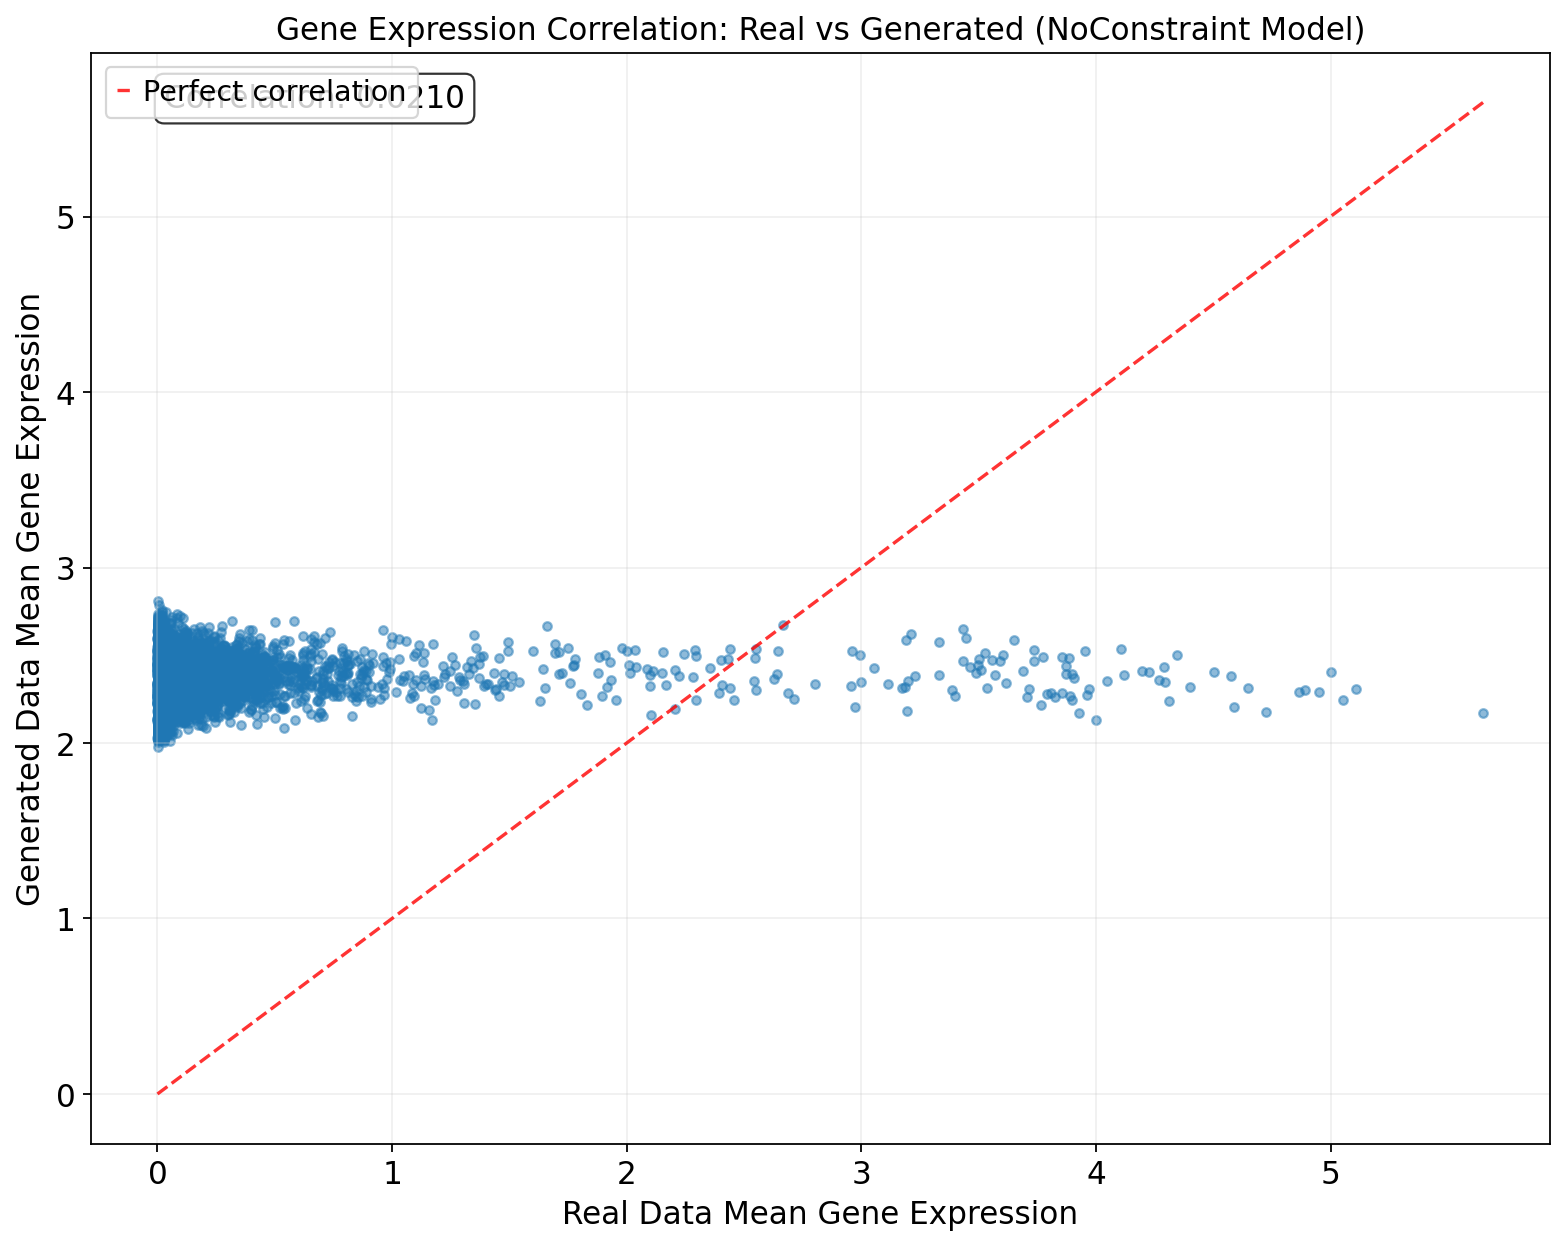

NoConstraint model generation correlation: 0.0210


In [7]:
# Analyze gene expression correlation between real and generated data
if cell_gen is not None:
    # Calculate mean expression per gene
    real_gene_means = cell_data.mean(axis=0)
    gen_gene_means = cell_gen.mean(axis=0)
    
    # Plot correlation
    plt.figure(figsize=(10, 8))
    plt.scatter(real_gene_means, gen_gene_means, alpha=0.5, s=15)
    plt.xlabel('Real Data Mean Gene Expression')
    plt.ylabel('Generated Data Mean Gene Expression')
    plt.title('Gene Expression Correlation: Real vs Generated (NoConstraint Model)')
    
    # Add diagonal line
    min_val = min(real_gene_means.min(), gen_gene_means.min())
    max_val = max(real_gene_means.max(), gen_gene_means.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, label='Perfect correlation')
    
    # Calculate correlation
    corr_coef = np.corrcoef(real_gene_means, gen_gene_means)[0, 1]
    plt.text(0.05, 0.95, f'Correlation: {corr_coef:.4f}', transform=plt.gca().transAxes, 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"NoConstraint model generation correlation: {corr_coef:.4f}")
else:
    print("No generated data available for correlation analysis")

In [8]:
# Create AnnData object for UMAP analysis
print("Creating combined dataset for UMAP analysis...")

if cell_gen is not None:
    # Combine real and generated data
    combined_data = np.concatenate((cell_data, cell_gen), axis=0)
    print(f"Combined data shape: {combined_data.shape}")
    
    # Create cell origin labels
    n_real = cell_data.shape[0]
    n_gen = cell_gen.shape[0]
    cell_origin = ['Real'] * n_real + ['Generated'] * n_gen
    
    # Create AnnData object
    adata_combined = sc.AnnData(X=combined_data)
    adata_combined.obs['cell_origin'] = cell_origin
    
    # Add real cell type information
    real_celltypes = adata.obs['celltype'].values
    all_celltypes = list(real_celltypes) + ['Generated'] * n_gen
    adata_combined.obs['celltype'] = all_celltypes
    
    print(f"AnnData object created: {adata_combined.shape}")
    print(f"Cell origin distribution: {adata_combined.obs['cell_origin'].value_counts()}")
    
else:
    print("Error: Generated data not available")

Creating combined dataset for UMAP analysis...
Combined data shape: (71579, 17789)
AnnData object created: (71579, 17789)
Cell origin distribution: cell_origin
Real         68579
Generated     3000
Name: count, dtype: int64


In [9]:
# Run UMAP preprocessing and analysis
print("Running UMAP analysis...")

if 'adata_combined' in locals():
    # Basic preprocessing for UMAP
    print("Scaling data...")
    sc.pp.scale(adata_combined, max_value=10)
    
    print("Running PCA...")
    sc.tl.pca(adata_combined, svd_solver='arpack', n_comps=50)
    
    print("Computing neighbors...")
    sc.pp.neighbors(adata_combined, n_neighbors=15, n_pcs=40)
    
    print("Computing UMAP...")
    sc.tl.umap(adata_combined)
    
    print("UMAP computation completed!")
    print(f"UMAP coordinates shape: {adata_combined.obsm['X_umap'].shape}")
    
else:
    print("Error: Combined data not available")

Running UMAP analysis...
Scaling data...
Running PCA...
computing PCA
    with n_comps=50
    finished (0:01:34)
Computing neighbors...
computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:24)
Computing UMAP...
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:35)
UMAP computation completed!
UMAP coordinates shape: (71579, 2)


## UMAP Visualization: Real vs Generated (NoConstraint Model)

Creating UMAP visualizations...


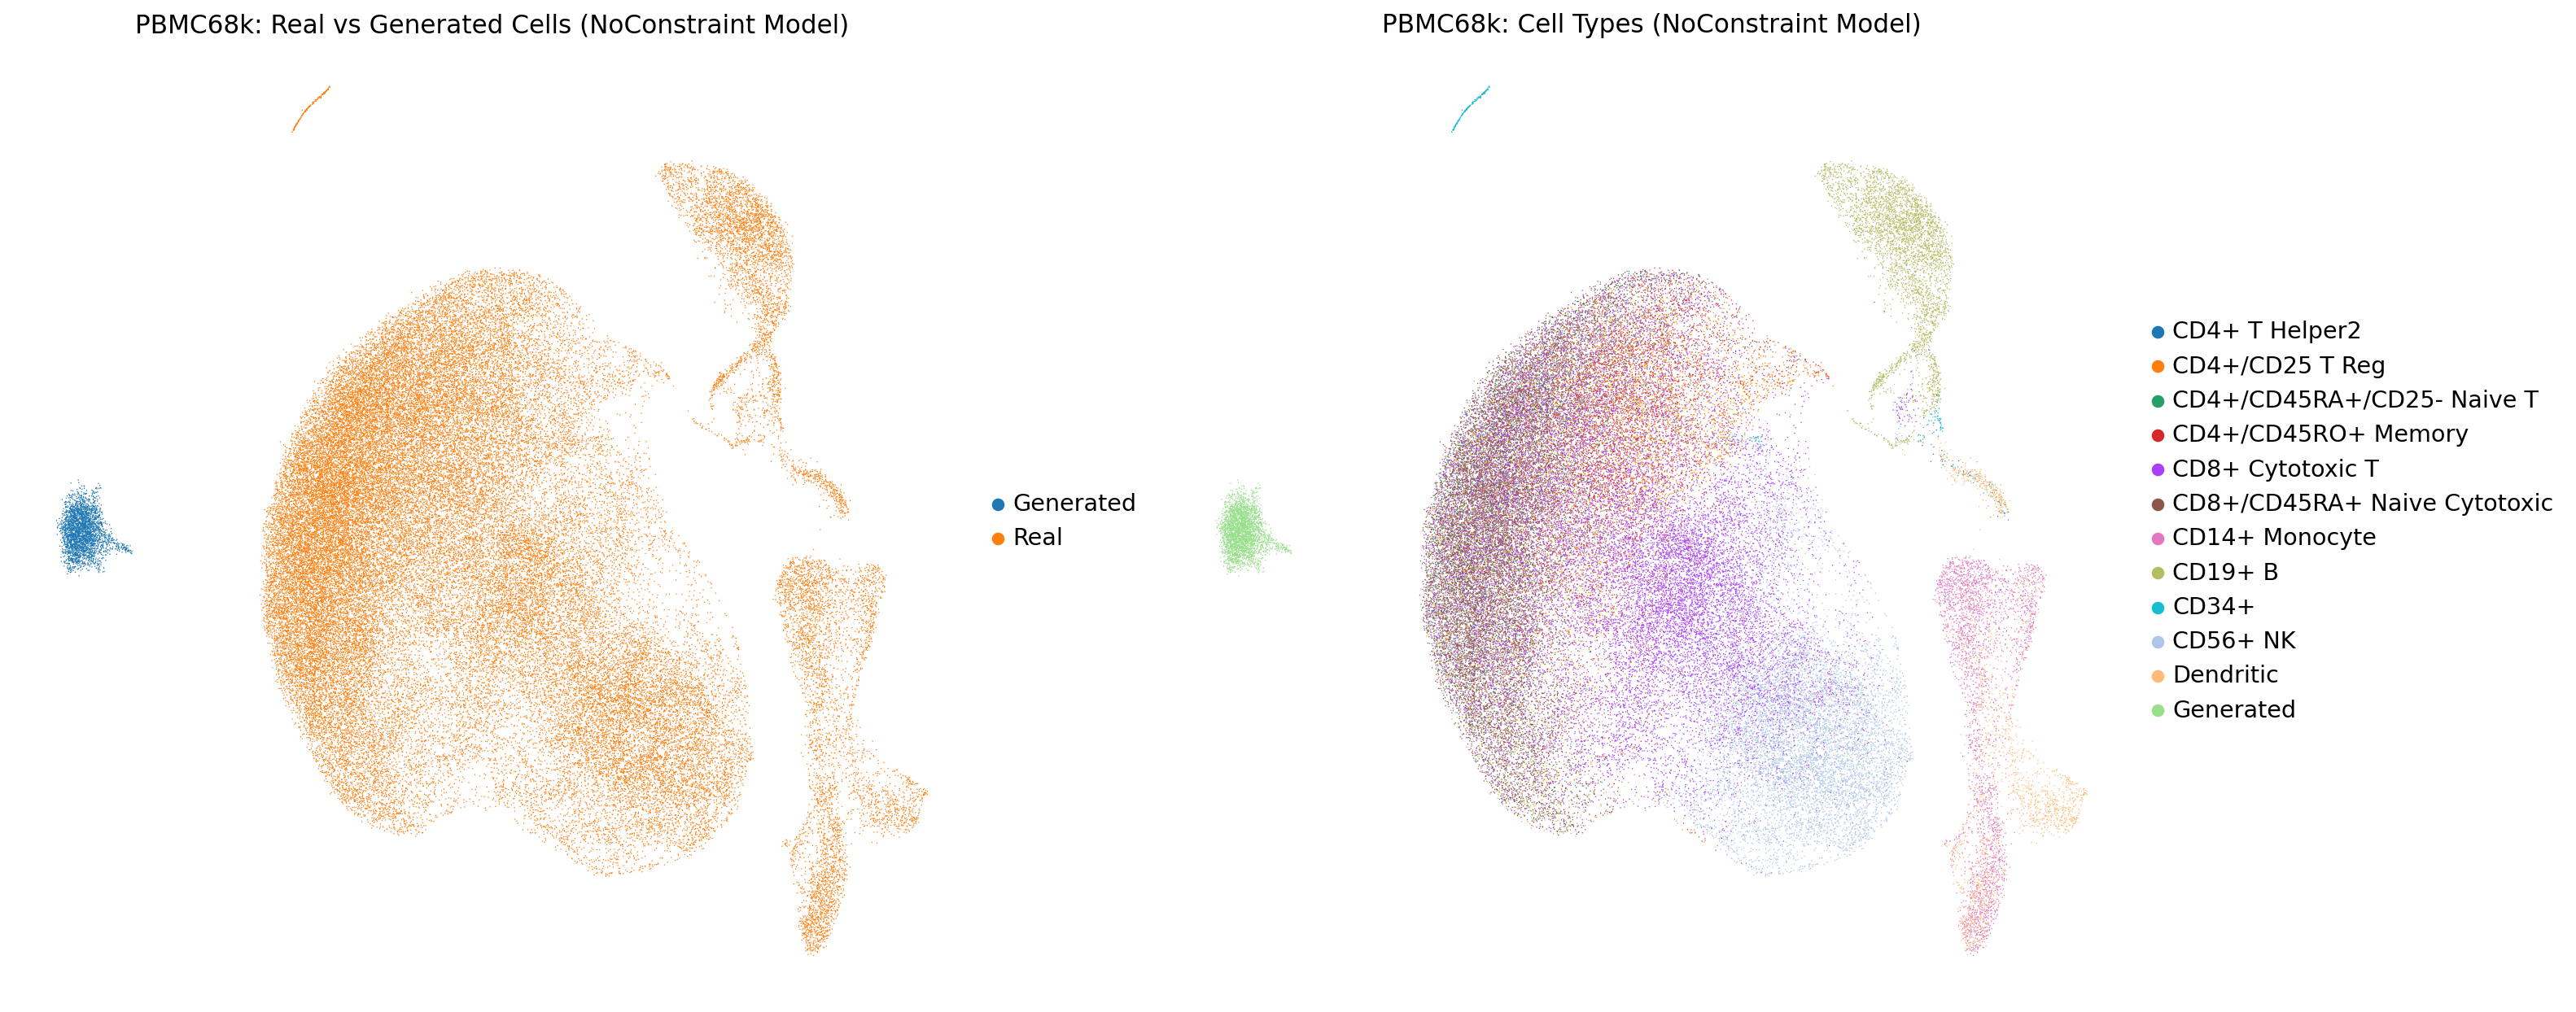

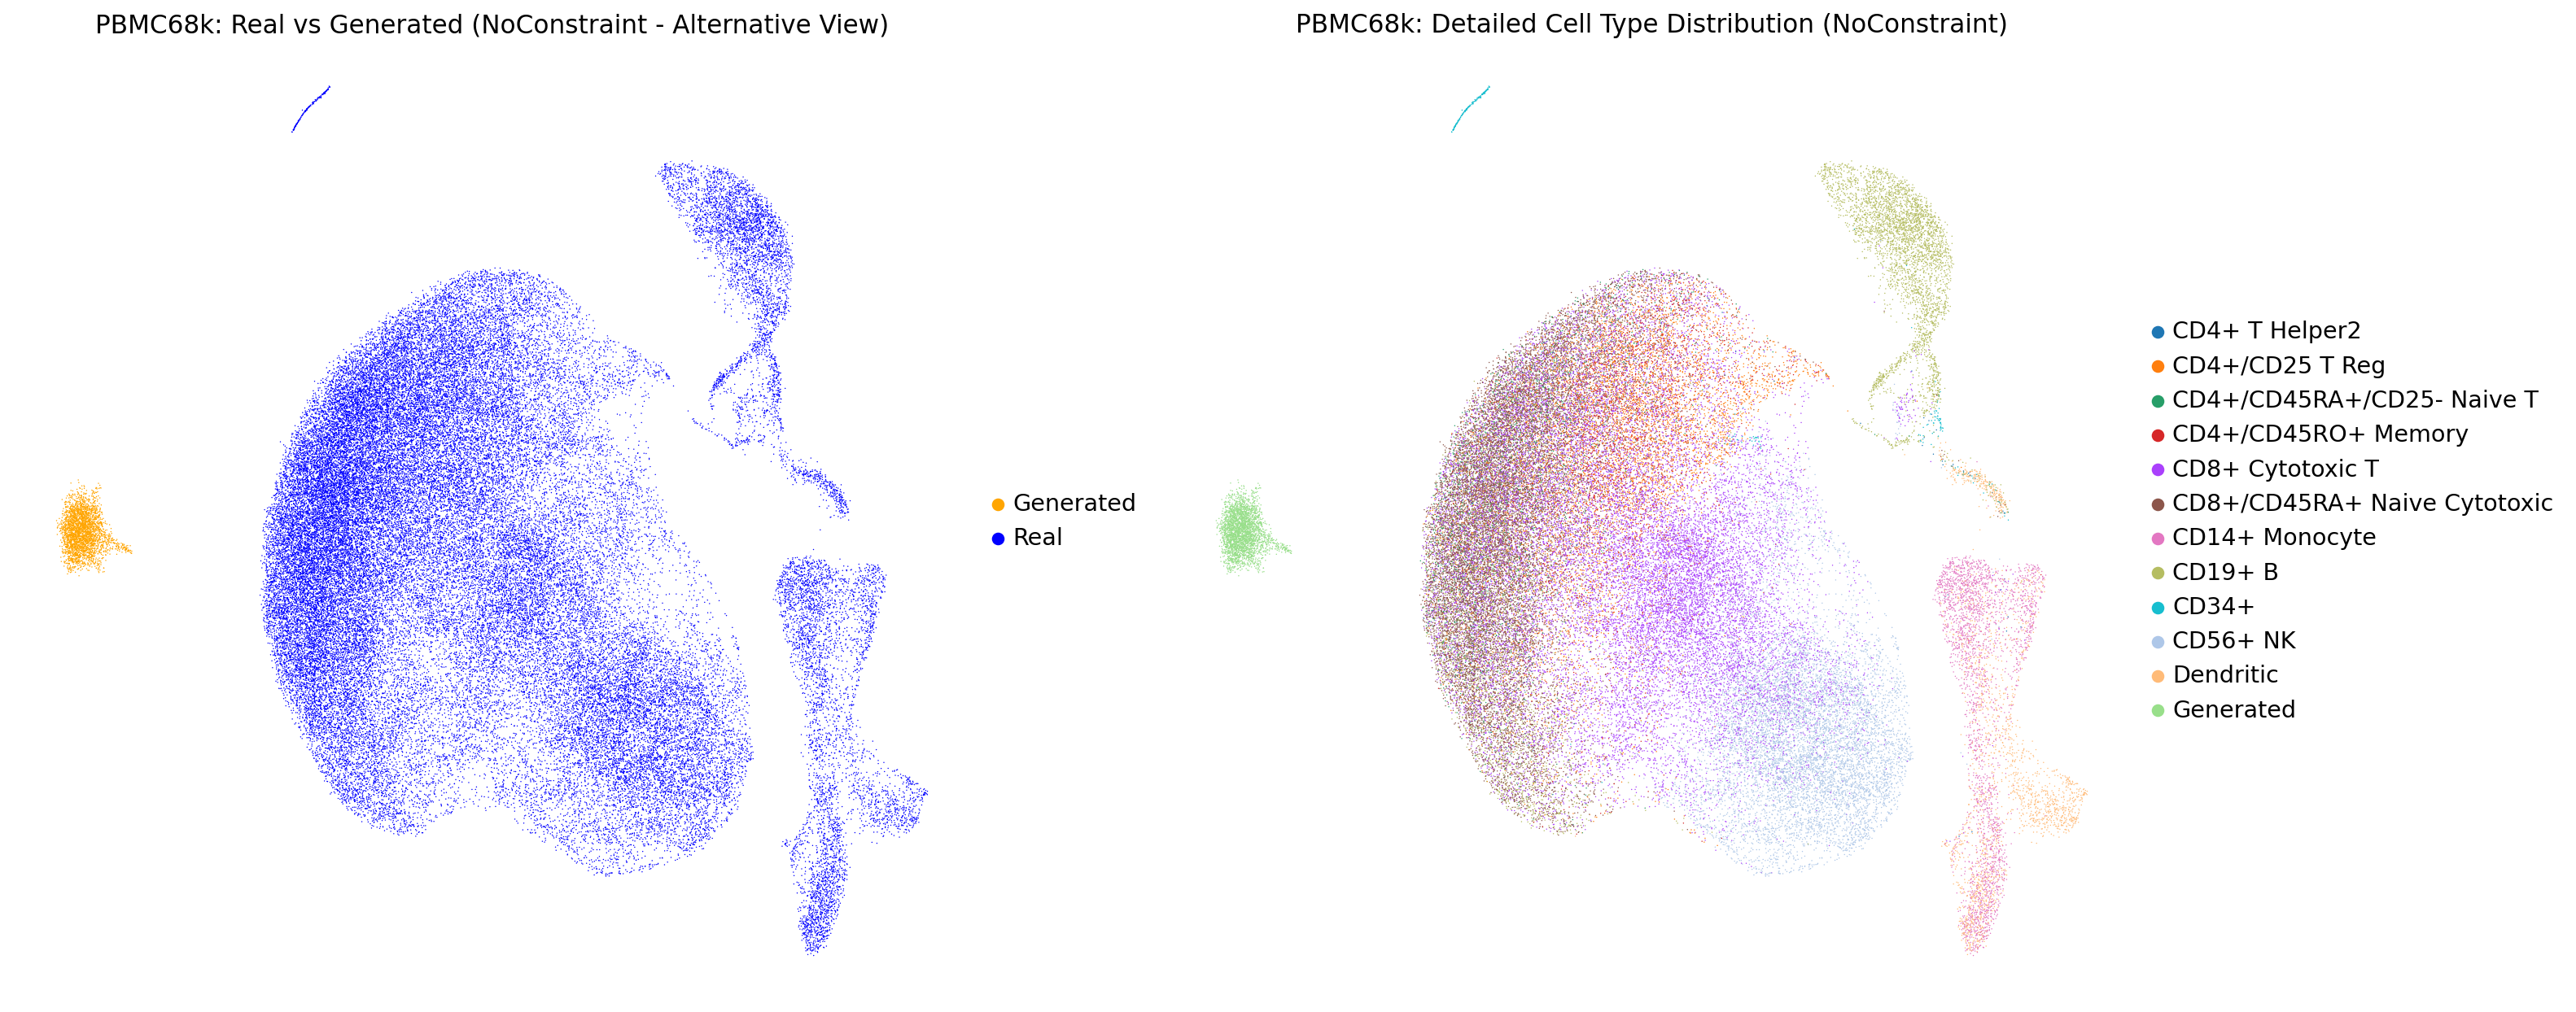

UMAP visualization completed!


In [10]:
if 'adata_combined' in locals() and 'X_umap' in adata_combined.obsm:
    print("Creating UMAP visualizations...")
    
    # Create UMAP plots
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # Plot 1: Real vs Generated
    sc.pl.umap(adata_combined, 
               color='cell_origin', 
               ax=axes[0], 
               title='PBMC68k: Real vs Generated Cells (NoConstraint Model)', 
               frameon=False, 
               show=False)
    
    # Plot 2: Cell Types
    sc.pl.umap(adata_combined, 
               color='celltype', 
               ax=axes[1], 
               title='PBMC68k: Cell Types (NoConstraint Model)', 
               frameon=False, 
               show=False)
    
    plt.tight_layout()
    plt.show()
    
    # Alternative view with different color scheme
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    sc.pl.umap(adata_combined, 
               color='cell_origin', 
               palette=['orange', 'blue'], 
               ax=axes[0], 
               title='PBMC68k: Real vs Generated (NoConstraint - Alternative View)', 
               frameon=False, 
               show=False)
    
    sc.pl.umap(adata_combined, 
               color='celltype', 
               ax=axes[1], 
               title='PBMC68k: Detailed Cell Type Distribution (NoConstraint)', 
               frameon=False, 
               show=False)
    
    plt.tight_layout()
    plt.show()
    
    print("UMAP visualization completed!")
else:
    print("UMAP results not available. Please run preprocessing first.")

## Gene Network Analysis (NoConstraint Model)

In [11]:
# Gene Network Analysis - Compare real and generated data networks
print("=== GENE NETWORK ANALYSIS (NoConstraint Model) ===")

# Import gene network metrics
import sys
sys.path.append('/home/suzuki/Projects/scDiffusion')
from metrics.gene_network_metrics import make_weighted_graph_from_adata, adjacency_correlation

if 'cell_data' in locals() and 'cell_gen' in locals():
    try:
        # Create separate AnnData objects for real and generated data
        print("Creating AnnData objects for network analysis...")
        
        # Create real data AnnData
        adata_real = sc.AnnData(X=cell_data)
        adata_real.var_names = [f"Gene_{i}" for i in range(cell_data.shape[1])]
        print(f"Real data AnnData: {adata_real.shape}")
        
        # Create generated data AnnData  
        adata_gen = sc.AnnData(X=cell_gen)
        adata_gen.var_names = [f"Gene_{i}" for i in range(cell_gen.shape[1])]
        print(f"Generated data AnnData: {adata_gen.shape}")
        
        # Ensure same gene names for comparison
        common_genes = list(set(adata_real.var_names) & set(adata_gen.var_names))
        print(f"Common genes for network analysis: {len(common_genes)}")
        
        # Subset to common genes
        adata_real_sub = adata_real[:, common_genes].copy()
        adata_gen_sub = adata_gen[:, common_genes].copy()
        
        print(f"Real data subset: {adata_real_sub.shape}")
        print(f"Generated data subset: {adata_gen_sub.shape}")
        
        # Create gene networks using PCA-based embeddings
        print("\\nCreating gene networks...")
        print("Building real data gene network...")
        graph_real = make_weighted_graph_from_adata(adata_real_sub, n_components=50)
        print(f"Real network: {graph_real.vcount()} vertices, {graph_real.ecount()} edges")
        
        print("Building generated data gene network...")
        graph_gen = make_weighted_graph_from_adata(adata_gen_sub, n_components=50)
        print(f"Generated network: {graph_gen.vcount()} vertices, {graph_gen.ecount()} edges")
        
        # Calculate network similarity
        print("\\nCalculating network similarity...")
        network_correlation = adjacency_correlation(graph_real, graph_gen)
        print(f"Gene network correlation (NoConstraint): {network_correlation:.4f}")
        
        # Additional network statistics
        print("\\n=== NETWORK STATISTICS (NoConstraint) ===")
        
        # Real network stats
        real_weights = [e["weight"] for e in graph_real.es]
        real_mean_weight = np.mean(real_weights)
        real_std_weight = np.std(real_weights)
        real_density = graph_real.density()
        
        print(f"Real network:")
        print(f"  Mean edge weight: {real_mean_weight:.4f}")
        print(f"  Std edge weight: {real_std_weight:.4f}")
        print(f"  Network density: {real_density:.4f}")
        
        # Generated network stats
        gen_weights = [e["weight"] for e in graph_gen.es]
        gen_mean_weight = np.mean(gen_weights)
        gen_std_weight = np.std(gen_weights)
        gen_density = graph_gen.density()
        
        print(f"Generated network:")
        print(f"  Mean edge weight: {gen_mean_weight:.4f}")
        print(f"  Std edge weight: {gen_std_weight:.4f}")
        print(f"  Network density: {gen_density:.4f}")
        
        # Weight distribution comparison
        print(f"\\nWeight distribution comparison:")
        print(f"  Weight correlation: {np.corrcoef(real_weights, gen_weights)[0,1]:.4f}")
        print(f"  Weight difference (mean): {abs(real_mean_weight - gen_mean_weight):.4f}")
        print(f"  Weight difference (std): {abs(real_std_weight - gen_std_weight):.4f}")
        
        print("\\nGene network analysis completed!")
        
    except Exception as e:
        print(f"Error in gene network analysis: {e}")
        import traceback
        traceback.print_exc()
        
else:
    print("Error: cell_data or cell_gen not available for network analysis")

=== GENE NETWORK ANALYSIS (NoConstraint Model) ===
Creating AnnData objects for network analysis...
Real data AnnData: (68579, 17789)
Generated data AnnData: (3000, 17789)
Common genes for network analysis: 17789
Real data subset: (68579, 17789)
Generated data subset: (3000, 17789)
\nCreating gene networks...
Building real data gene network...


KeyboardInterrupt: 

In [ ]:
adata_combined.obs["celltype"].unique()

In [ ]:
# Separate cells based on whether celltype starts with "gen"
gen_mask = adata_combined.obs["celltype"].str.startswith("gen")
non_gen_mask = ~gen_mask

print(f"Cells with 'gen' celltype: {gen_mask.sum()}")
print(f"Cells without 'gen' celltype: {non_gen_mask.sum()}")

# Create separate AnnData objects
adata_gen = adata_combined[gen_mask].copy()
adata_non_gen = adata_combined[non_gen_mask].copy()

print(f"Generated cells data shape: {adata_gen.shape}")
print(f"Real cells data shape: {adata_non_gen.shape}")

# Create UMAP plots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# UMAP for generated cells (starting with "gen")
sc.pl.umap(adata_gen, 
           color='celltype', 
           ax=axes[0], 
           title='Generated Cells (NoConstraint Model)', 
           frameon=False, 
           show=False)

# UMAP for real cells (not starting with "gen")
sc.pl.umap(adata_non_gen, 
           color='celltype', 
           ax=axes[1], 
           title='Real Cells (NoConstraint Model)', 
           frameon=False, 
           show=False)

plt.tight_layout()
plt.show()

# Create PCA plots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# PCA for generated cells (starting with "gen")
sc.pl.pca(adata_gen, 
          color='celltype', 
          ax=axes[0], 
          title='Generated Cells PCA (NoConstraint Model)', 
          frameon=False, 
          show=False)

# PCA for real cells (not starting with "gen")
sc.pl.pca(adata_non_gen, 
          color='celltype', 
          ax=axes[1], 
          title='Real Cells PCA (NoConstraint Model)', 
          frameon=False, 
          show=False)

plt.tight_layout()
plt.show()

print("UMAP and PCA plots created for generated vs real cells (NoConstraint Model)!")

In [ ]:
from itertools import chain

# ──────────────────────────────────────────────────────────
# 0. 前提: adata_combined には
#    obs["celltype"] = 〔実細胞クラスタ〕 ∪ 〔"gen " + 実クラスタ〕 が入っている
# ──────────────────────────────────────────────────────────

# ──────────────────────────────────────────────────────────
# 1. 実クラスタのみ取り出してマーカー遺伝子解析
# ──────────────────────────────────────────────────────────
is_real = ~adata_combined.obs["celltype"].str.startswith("gen")
adata_real = adata_combined[is_real].copy()   # ★ 解析対象は実細胞のみ

sc.tl.rank_genes_groups(
    adata_real,
    groupby      = "celltype",           # クラスタ列
    reference    = "rest",               # 各クラスタ vs. 残り全部
    method       = "wilcoxon",
    n_genes      = adata_real.shape[1]   # すべての遺伝子で検定
)

# ──────────────────────────────────────────────────────────
# 2. 各クラスタで P_adj < 0.001 かつ |logFC| が大きい
#    上位 20 遺伝子を抜き出し辞書にまとめる
# ──────────────────────────────────────────────────────────

marker_dict = {}                         # {cluster: [gene1, …, gene20]}
for clust in adata_real.obs["celltype"].cat.categories:
    df = sc.get.rank_genes_groups_df(adata_real, group=clust)              # 全遺伝子
    df["logfoldchanges_abs"] =df["logfoldchanges"].abs()
    df.sort_values("logfoldchanges_abs", ascending=False, inplace=True)  # |logFC| 降順
    df = df[df["pvals_adj"] < 0.05]                                       # P_adj < 0.001
                                                  # 上位
    top20 = df.head(20)["names"].tolist()
    marker_dict[clust] = top20
    print(clust)
    print(len(top20))
#==========================================================

"""
per‑cluster MATRIXPLOT (2×1: real / gen) を
カレントディレクトリ直下  cluster_plots/ に保存する (NoConstraint Model)
────────────────────────────────────────────
前提:
    • adata_combined : 実＋生成 AnnData
    • marker_dict    : {cluster_name: [top‑20 genes…]}  ← ①‑② で作成済み
"""

import os, re, scanpy as sc, matplotlib.pyplot as plt

# ───────────────────────────────────────────
# 0. 保存先ディレクトリを scanpy のデフォルトに設定
# ───────────────────────────────────────────
FIGDIR = os.path.join(os.getcwd(), "cluster_plots_NoConstraint")
os.makedirs(FIGDIR, exist_ok=True)
sc.settings.figdir = FIGDIR          # save= の既定出力先

def sanitize(name: str) -> str:
    """ファイル名に使えない文字を _ に置換"""
    return re.sub(r"[^\w\-]", "_", name)

# パラメータ
GENES_PER_CLUSTER = 20
real_clusters     = list(marker_dict.keys())

# ───────────────────────────────────────────
# 1. 各クラスタで 2×1 subplot を作成
# ───────────────────────────────────────────
for clust in real_clusters:
    gen_label = f"gen {clust}"
    genes_all = marker_dict[clust][:GENES_PER_CLUSTER]

    # ── Figure / Axes 作成 ───────────────────────────
    fig, axes = plt.subplots(
        nrows   = 2, ncols = 1,
        figsize = (8, 6),
        sharex  = False, sharey=False
    )

    # ── 0 行目: real sample ──────────────────────────
    sc.pl.matrixplot(
        adata_combined[is_real],
        var_names      = genes_all,
        groupby        = "celltype",
        cmap           = "bwr",
        standard_scale = "var",
        dendrogram     = False,
        swap_axes      = False,          # 列＝遺伝子・行＝celltype(=1 行)
        show           = False,
        ax             = axes[0],        # ← subplot 指定
    )

    # ── 1 行目: generated sample ─────────────────────
    sc.pl.matrixplot(
        adata_combined[~is_real],
        var_names      = genes_all,
        groupby        = "celltype",
        cmap           = "bwr",
        standard_scale = "var",
        dendrogram     = False,
        swap_axes      = False,
        show           = False,
        ax             = axes[1],
    )

    plt.tight_layout(h_pad=1.2)
    save_path = os.path.join(FIGDIR, f"{sanitize(clust)}_NoConstraint_dual_matrixplot.png")
    fig.savefig(save_path, dpi=300)
    plt.close(fig)

    print(f"✔  saved {save_path}")

print(f"✔  全クラスタの図を {FIGDIR} に保存しました。")

In [ ]:
adata_real

In [ ]:
adata_gen

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import igraph as ig

# 1) adata → 重み付きグラフ（頂点に embedding を保存）
def make_weighted_graph_from_adata(adata, n_components=50):
    X = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X   # (cells × genes)
    genes = np.array(adata.var_names)
    Xt = X.T  # (genes × cells)

    pca = PCA(n_components=n_components)
    emb = pca.fit_transform(Xt)   # (genes × 50)

    sim = cosine_similarity(emb)  # 類似度を重みとして使う（[-1,1]）

    g = ig.Graph.Weighted_Adjacency(sim.tolist(), mode="undirected", attr="weight", loops=False)
    g.vs["name"] = genes.tolist()
    # ← これが無いと後で KeyError になる
    g.vs["embedding"] = [e.tolist() for e in emb]

    return g

# 2) 2グラフの埋め込み類似度（共通遺伝子に揃えて平均コサイン）
def graph_embedding_similarity(g1, g2):
    # gene名で対応付け
    names1 = np.array(g1.vs["name"]); names2 = np.array(g2.vs["name"])
    common = np.intersect1d(names1, names2)
    if common.size == 0:
        raise ValueError("共通遺伝子がありません。")

    # 頂点順に注意：名前→インデックスの辞書で揃える
    idx1 = [g1.vs.find(name=n).index for n in common]
    idx2 = [g2.vs.find(name=n).index for n in common]

    emb1 = np.array(g1.vs["embedding"])[idx1]
    emb2 = np.array(g2.vs["embedding"])[idx2]

    # 共通遺伝子間で対応する行同士のコサインを平均
    # （別案：全対全コサインの平均/Top-k 平均なども可）
    num = np.sum(emb1 * emb2, axis=1)
    den = (np.linalg.norm(emb1, axis=1) * np.linalg.norm(emb2, axis=1) + 1e-12)
    per_gene_cos = num / den
    return float(np.mean(per_gene_cos))

# 3) 2グラフを共通遺伝子に揃えてLeiden→クラスタ一致度（ARI/NMI）
def compare_graphs_by_communities(g1, g2, resolution=1.0):
    # 共通遺伝子にサブグラフ化（順序を明示的に合わせる）
    names1 = np.array(g1.vs["name"]); names2 = np.array(g2.vs["name"])
    common = np.intersect1d(names1, names2)
    if common.size == 0:
        raise ValueError("共通遺伝子がありません。")

    # g1, g2 ともに common の順に頂点を並べ替え
    g1_sub = g1.subgraph([g1.vs.find(name=n).index for n in common])
    g2_sub = g2.subgraph([g2.vs.find(name=n).index for n in common])

    # Leiden（重み使用）
    c1 = g1_sub.community_leiden(weights="weight", resolution_parameter=resolution)
    c2 = g2_sub.community_leiden(weights="weight", resolution_parameter=resolution)

    labels1 = c1.membership
    labels2 = c2.membership

    # 一致度
    ari = adjusted_rand_score(labels1, labels2)
    nmi = normalized_mutual_info_score(labels1, labels2)

    return {
        "genes": common,            # 比較に使った遺伝子順
        "partition1": c1,           # igraph.VertexClustering
        "partition2": c2,           # igraph.VertexClustering
        "ari": float(ari),
        "nmi": float(nmi),
    }

In [ ]:
g_real = make_weighted_graph_from_adata(adata_real, n_components=50)
g_gen  = make_weighted_graph_from_adata(adata_gen,  n_components=50)

# 埋め込みレベルの近さ（共通遺伝子で平均コサイン）
sim_score = graph_embedding_similarity(g_real, g_gen)
print("Embedding similarity (mean cosine) - NoConstraint Model:", sim_score)

# コミュニティ（Leiden）一致度
res = compare_graphs_by_communities(g_real, g_gen, resolution=1.0)
print("ARI:", res["ari"], "NMI:", res["nmi"], "#genes:", len(res["genes"]))